In [1]:
pip install nltk


Term frequencies for Abstract 1
accuracy: 1
accurate: 1
accurately: 1
achieved: 1
address: 1
affect: 1
ai: 3
aid: 1
aim: 1
algorithm: 1
alike: 2
allowing: 1
artificial: 1
automatically: 2
automation: 1
based: 1
causes: 2
conducting: 1
course: 1
deep: 2
designed: 1
drugs: 2
efforts: 1
ensuring: 1
error: 1
errors: 6
expected: 1
help: 1
highest: 1
however: 1
human: 1
implemented: 1
independently: 1
information: 1
intelligence: 1
issue: 1
labeling: 1
lasa: 3
leading: 1
leads: 1
learn: 1
learned: 1
learning: 2
look: 1
made: 1
managing: 1
medication: 6
medications: 2
methods: 1
needed: 1
networks: 1
neural: 1
one: 2
part: 1
patient: 2
predicted: 1
predictions: 2
previous: 1
processes: 1
proven: 1
providing: 1
receiving: 1
recurrent: 1
reduce: 3
report: 1
research: 1
rnn: 2
safety: 2
serving: 1
solutions: 1
sound: 1
storing: 1
studies: 1
study: 1
system: 1
systems: 1
technology: 2
testing: 1
thereby: 1
training: 2
using: 1
utilization: 2
widely: 1
works: 1

Term frequencies for Abstract 2
ac

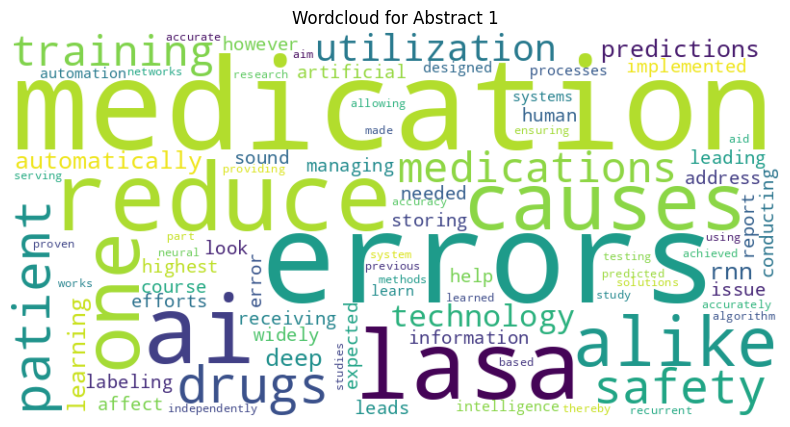

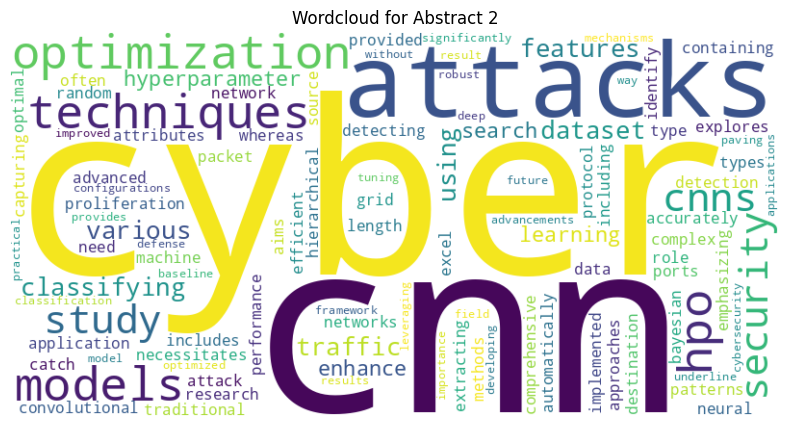

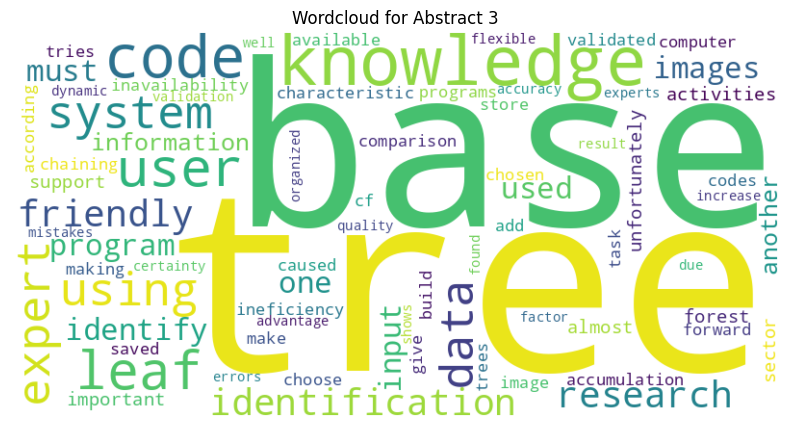

In [9]:
import re
from collections import Counter
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

# Download stopwords
# nltk.download('stopwords')

# English stopwords
stop_words = set(stopwords.words('english'))

# List of abstracts
abstracts = [
    """Report from the WHO that one of the highest causes of medication errors is Look Alike – Sound Alike (LASA) drugs, leading to errors in receiving information about the drugs, which of course will affect patient safety. Efforts to reduce medication errors have been widely implemented, such as conducting medication training, managing medications, and storing and labeling medications. However, all of that leads to human error, so the utilization of technology is needed to address this issue. The technology expected to help reduce medication errors is the utilization of artificial intelligence (AI). AI is designed for automation processes and systems that can learn independently, allowing the causes of medication errors such as LASA to be learned by the system and predicted automatically. Deep learning is a part of AI that works by providing solutions accurately and automatically. The Recurrent Neural Networks (RNN) algorithm is one of the deep learning methods that has been proven accurate in predictions based on previous research studies. In this study, LASA predictions were made using RNN with the aim of serving as an aid to reduce medication errors, thereby ensuring patient safety. The accuracy achieved is 99% for training and 81% for testing.""",

    """The proliferation of cyber security attacks necessitates advanced and efficient detection methods. This study explores the application of Convolutional Neural Networks (CNNs) for classifying cyber security attacks using a comprehensive dataset containing various attack types and network traffic features. Emphasizing the role of hyperparameter optimization (HPO) techniques, this research aims to enhance the CNN model's performance in accurately detecting and classifying cyber attacks. Traditional machine learning approaches often need to catch up in capturing the complex patterns in such data, whereas CNNs excel in automatically extracting hierarchical features. Using the provided dataset, which includes attributes such as packet length, source and destination ports, protocol, and traffic type, we implemented various (HPO) techniques, including Grid Search, Random Search, and Bayesian Optimization, to identify the optimal CNN configurations. Our optimized CNN model significantly improved classification result. to baseline models without hyperparameter tuning. The results underline the importance of HPO in developing robust CNN models for cybersecurity applications. This study provides a practical framework for leveraging deep learning and optimization techniques to enhance cyber defense mechanisms, paving the way for future advancements in the field.""",

    """Tree identification is a very important to support almost all activities in the forest sector. Unfortunately, the inavailability of data and computer programs that is user friendly have caused ineficiency in tree identification. This research tries to make an expert system to identify trees by using the leaf images. To store the data in the knowledge base one must choose one of the some leaf images that are in the data base available in the program according the characteristic of the leaf. Each leaf image has a code and the accumulation of all codes build a tree code then this code is saved in the knowledge base. The tree code is used to identify a tree by making the comparison between input chosen by user and the tree code in the knowledge base using forward chaining. User who has information about a tree can add to the knowledge base but this information must be validated by an expert before it is used in the system. Another task of an expert is to give a CF (certainty factor) for each tree. The result of this research shows that no more errors are found due to input mistakes and the program is more user friendly. Another advantage is that the knowledge base is more flexible, dynamic and well organized Validation of knowledge base by experts can increase the quality and accuracy of using the knowledge base system."""
]

# Function to clean and tokenize text
def preprocess(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]', '', text)
  words = text.split()
  filtered = [word for word in words if word not in stop_words and len(word) > 1]
  return filtered

# Function to get term frequencies per abstract
def term_frequencies(abstract):
  for idx, text in enumerate(abstract, 1):
    words = preprocess(text)
    freq = Counter(words)
    print(f'\nTerm frequencies for Abstract {idx}')
    for term, count in sorted(freq.items()):
      print(f'{term}: {count}')

# Function to create wordclouds
def generate_wordclouds(abstracts):
  for idx, text in enumerate(abstracts, 1):
    words = preprocess(text)
    freq = Counter(words)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud for Abstract {idx}')
    plt.show()

# Call the functions
term_frequencies(abstracts)
generate_wordclouds(abstracts)

Cosine Similarity Matrix:

 [[1.    0.049 0.042]
 [0.049 1.    0.024]
 [0.042 0.024 1.   ]]


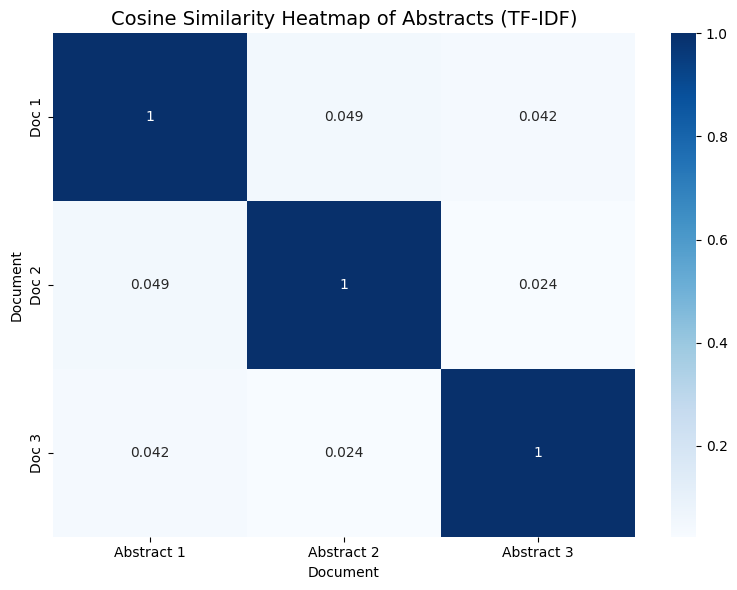

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
import numpy as np
import seaborn as sns

abstracts = [
    """Report from the WHO that one of the highest causes of medication errors is Look Alike – Sound Alike (LASA) drugs, leading to errors in receiving information about the drugs, which of course will affect patient safety. Efforts to reduce medication errors have been widely implemented, such as conducting medication training, managing medications, and storing and labeling medications. However, all of that leads to human error, so the utilization of technology is needed to address this issue. The technology expected to help reduce medication errors is the utilization of artificial intelligence (AI). AI is designed for automation processes and systems that can learn independently, allowing the causes of medication errors such as LASA to be learned by the system and predicted automatically. Deep learning is a part of AI that works by providing solutions accurately and automatically. The Recurrent Neural Networks (RNN) algorithm is one of the deep learning methods that has been proven accurate in predictions based on previous research studies. In this study, LASA predictions were made using RNN with the aim of serving as an aid to reduce medication errors, thereby ensuring patient safety. The accuracy achieved is 99% for training and 81% for testing.""",

    """The proliferation of cyber security attacks necessitates advanced and efficient detection methods. This study explores the application of Convolutional Neural Networks (CNNs) for classifying cyber security attacks using a comprehensive dataset containing various attack types and network traffic features. Emphasizing the role of hyperparameter optimization (HPO) techniques, this research aims to enhance the CNN model's performance in accurately detecting and classifying cyber attacks. Traditional machine learning approaches often need to catch up in capturing the complex patterns in such data, whereas CNNs excel in automatically extracting hierarchical features. Using the provided dataset, which includes attributes such as packet length, source and destination ports, protocol, and traffic type, we implemented various (HPO) techniques, including Grid Search, Random Search, and Bayesian Optimization, to identify the optimal CNN configurations. Our optimized CNN model significantly improved classification result. to baseline models without hyperparameter tuning. The results underline the importance of HPO in developing robust CNN models for cybersecurity applications. This study provides a practical framework for leveraging deep learning and optimization techniques to enhance cyber defense mechanisms, paving the way for future advancements in the field.""",

    """Tree identification is a very important to support almost all activities in the forest sector. Unfortunately, the inavailability of data and computer programs that is user friendly have caused ineficiency in tree identification. This research tries to make an expert system to identify trees by using the leaf images. To store the data in the knowledge base one must choose one of the some leaf images that are in the data base available in the program according the characteristic of the leaf. Each leaf image has a code and the accumulation of all codes build a tree code then this code is saved in the knowledge base. The tree code is used to identify a tree by making the comparison between input chosen by user and the tree code in the knowledge base using forward chaining. User who has information about a tree can add to the knowledge base but this information must be validated by an expert before it is used in the system. Another task of an expert is to give a CF (certainty factor) for each tree. The result of this research shows that no more errors are found due to input mistakes and the program is more user friendly. Another advantage is that the knowledge base is more flexible, dynamic and well organized Validation of knowledge base by experts can increase the quality and accuracy of using the knowledge base system."""
]

# TF-IDF Vectorizer with stopwords
Vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))

# Compute TF-IDF matrix
tfidf_matrix = Vectorizer.fit_transform(abstracts)

# Compute cosine similarity between documents
cosine_sim = cosine_similarity(tfidf_matrix)

print('Cosine Similarity Matrix:')
print('\n', np.round(cosine_sim, 3))

plt.figure(figsize=(8, 6))
sns.heatmap(cosine_sim, annot=True, cmap='Blues', xticklabels=["Abstract 1", "Abstract 2", "Abstract 3"], yticklabels=["Doc 1", "Doc 2", "Doc 3"])
plt.title('Cosine Similarity Heatmap of Abstracts (TF-IDF)', fontsize=14)
plt.xlabel('Document')
plt.ylabel('Document')
plt.tight_layout()
plt.show()